In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplot2tikz
import numpy as np

In [4]:
df = pd.read_csv('../log/20251211_mc.csv', header = None, names = ['dataset', 'train_fitness', 'test_fitness',  'parameters',
                                                        'depth', 'width', 'test_mcc', 'seed', 'generation', 'timing'])

In [5]:
df.head()

,dataset,train_fitness,test_fitness,parameters,depth,width,test_mcc,seed,generation,timing
0,mc_tuberculosis_rn18_10_cross_entropy,1.205618,1.255233,4273,1,4,0.424334,3,0,277.996082
1,mc_tuberculosis_rn18_10_cross_entropy,1.058877,1.100991,2579,1,3,0.288675,7,0,278.152235
2,mc_tuberculosis_rn18_10_cross_entropy,1.205618,1.255233,4273,1,4,0.424334,3,1,0.085632
3,mc_tuberculosis_rn18_10_cross_entropy,1.058877,1.100991,2579,1,3,0.288675,7,1,0.097939
4,mc_tuberculosis_rn18_10_cross_entropy,1.205616,1.255335,4819,2,4,0.424334,3,2,0.134936


In [8]:
df.drop_duplicates(subset =['dataset', 'seed', 'generation'], inplace = True, keep = 'last')

In [6]:
datas = df.dataset.unique()

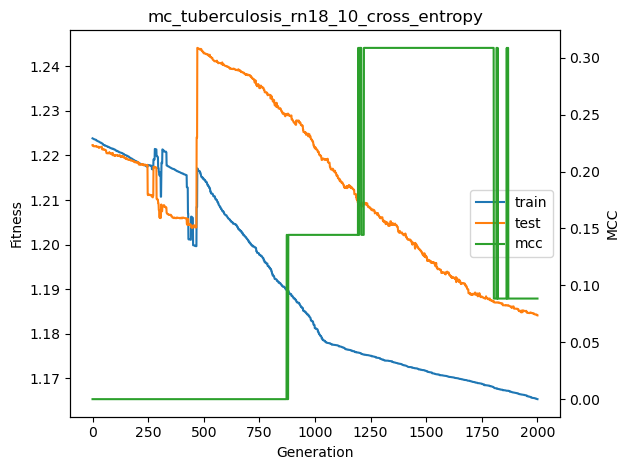

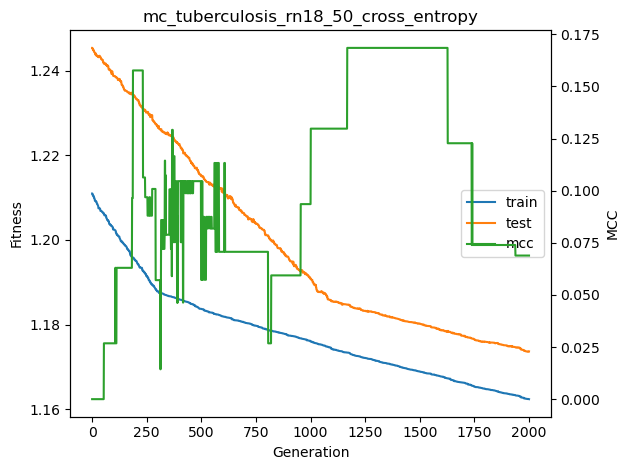

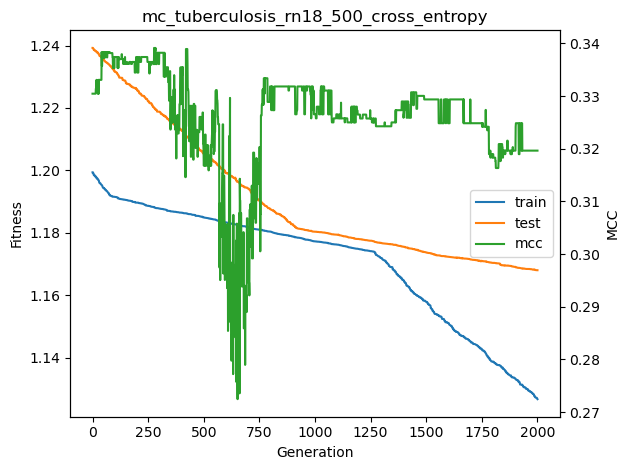

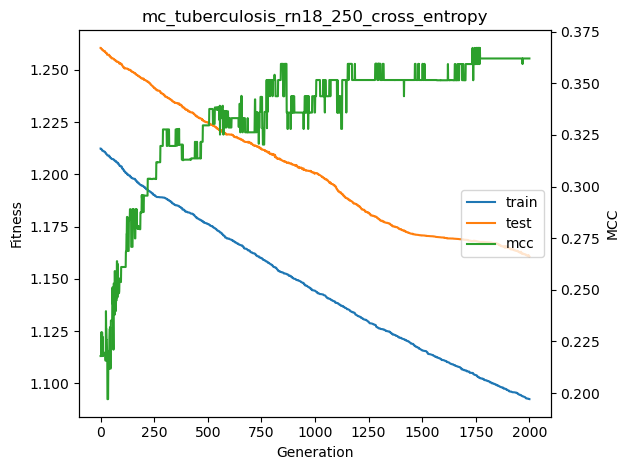

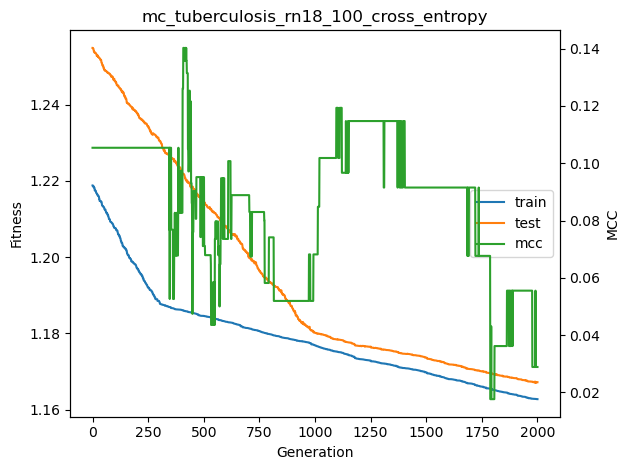

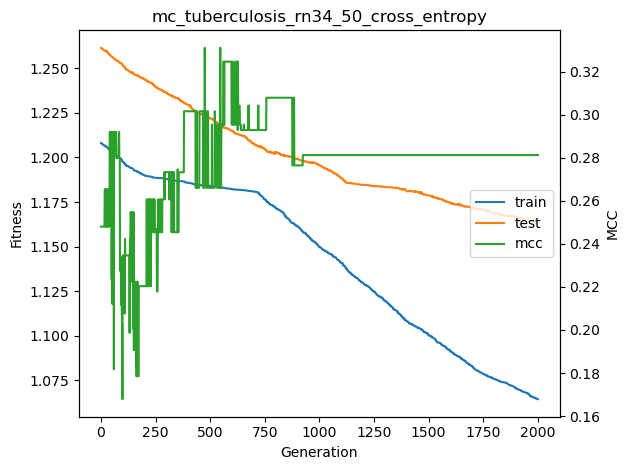

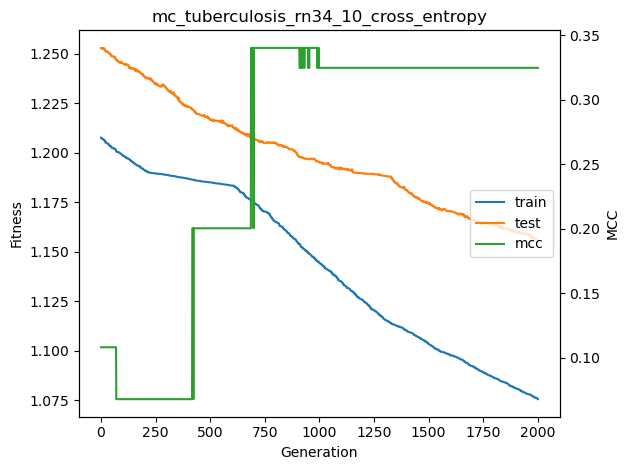

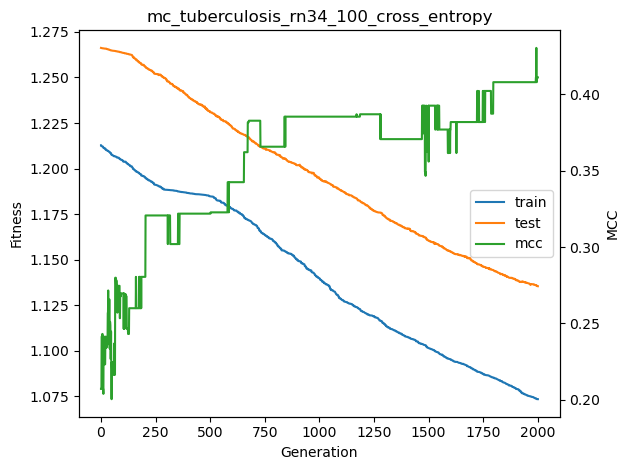

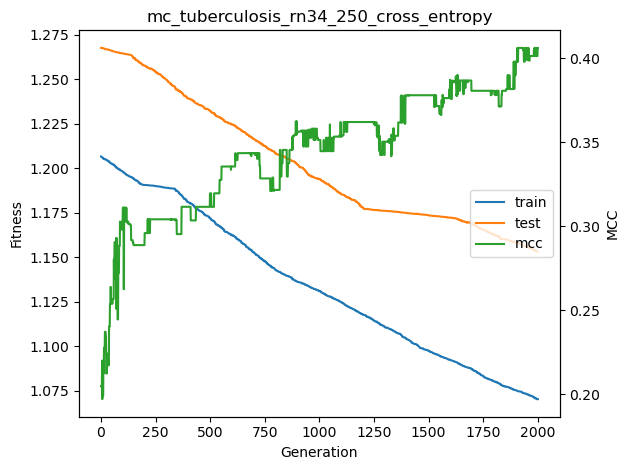

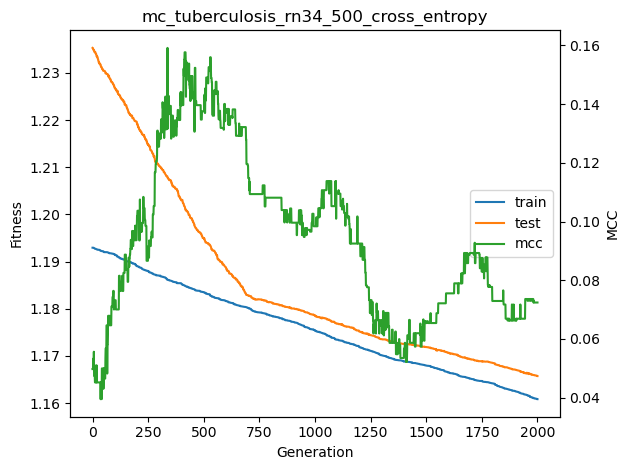

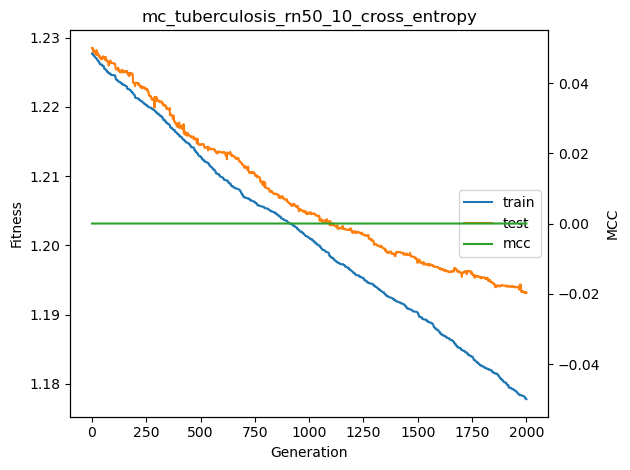

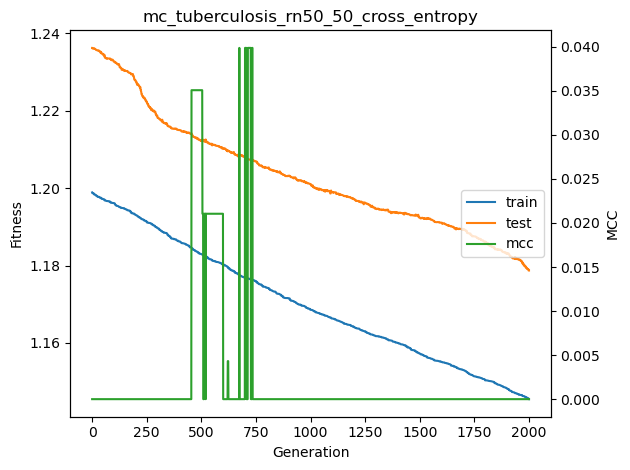

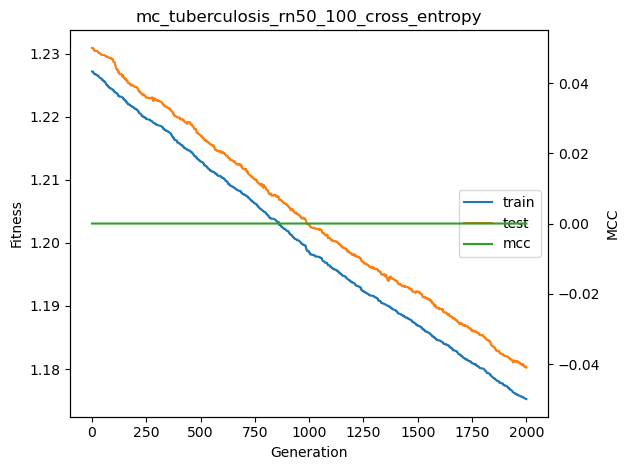

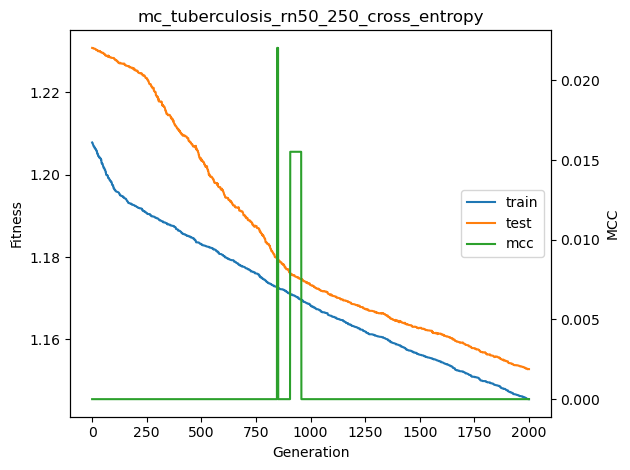

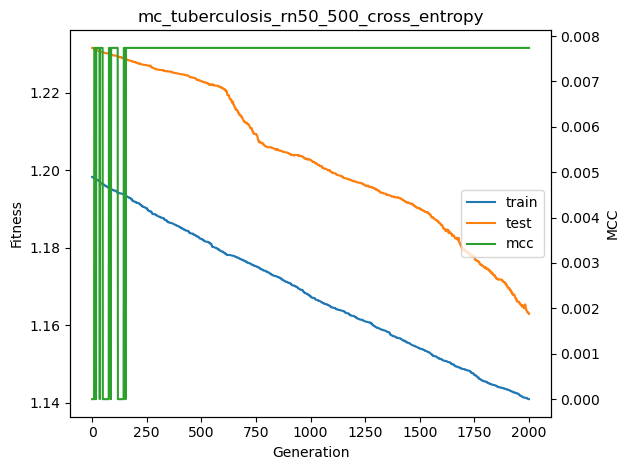

In [11]:
for dataset in datas:
    fig, ax1 = plt.subplots()
    
    grouped = df[(df['dataset'] == dataset)][
                    ['train_fitness', 'test_fitness', 'test_mcc', 'generation']].groupby('generation').median()
    
    # Primary y-axis for fitness
    ax1.plot(grouped.index, grouped.train_fitness, label='train', color='tab:blue')
    ax1.plot(grouped.index, grouped.test_fitness, label='test', color='tab:orange')
    ax1.set_xlabel('Generation')
    ax1.set_ylabel('Fitness')
    
    # Secondary y-axis for MCC
    ax2 = ax1.twinx()
    ax2.plot(grouped.index, grouped.test_mcc, label='mcc', color='tab:green')
    ax2.set_ylabel('MCC')
    
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
    
    plt.title(dataset)
    plt.tight_layout()
    plt.show()